In [2]:
device = "cuda"

In [3]:
import torch
torch.cuda.is_available()

True

In [4]:
import numpy as np 
import pandas as pd
import matplotlib as plt 
import seaborn as sns

In [5]:
dataset = pd.read_csv("Churn_Modelling.csv")

In [6]:
dataset.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# Problem statement
- Weather the customer will stay or exit the company in the furure, so we need to prevent the leakage of the customers by providing more services to them.
- It is a binary classification problem

In [7]:
# Find the features and target variables 
X = dataset.iloc[:,3:13]
Y = dataset.iloc[:,13]

In [8]:
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [9]:
Y.head()

0    1
1    0
2    1
3    0
4    0
Name: Exited, dtype: int64

# Check class imbalance 
The dataset is mild imbalanced there are 7963 (79%) customers not exit from the bank and 2037 (20%) exited from the bank. which is 3.9 : 1. To make this balance we apply SMOT technique after train test split why we applying SMOT after slpit because the test data should remain unchnaged.

In [10]:
print(Y.value_counts())
print(Y.value_counts(normalize=True) * 100)

Exited
0    7963
1    2037
Name: count, dtype: int64
Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


# Feature Engineering
- Since the feature variables contain categorical information lets apply Onehot encoding.

In [11]:
from sklearn.preprocessing import OneHotEncoder
Geography = pd.get_dummies(X['Geography'],drop_first=True).astype(int)
Gender = pd.get_dummies(X['Gender']).astype(int)

In [12]:
Gender

,Female,Male
0,1,0
1,1,0
2,1,0
3,1,0
4,1,0
...,...,...
9995,0,1
9996,0,1
9997,1,0
9998,0,1


In [13]:
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [14]:
# drop 'Geography','Gender' from X and concatinate with onehot values 
X = X.drop(['Geography', 'Gender'], axis = 1)
X

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,42,2,0.00,1,1,1,101348.88
1,608,41,1,83807.86,1,0,1,112542.58
2,502,42,8,159660.80,3,1,0,113931.57
3,699,39,1,0.00,2,0,0,93826.63
4,850,43,2,125510.82,1,1,1,79084.10
...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64
9996,516,35,10,57369.61,1,1,1,101699.77
9997,709,36,7,0.00,1,0,1,42085.58
9998,772,42,3,75075.31,2,1,0,92888.52


In [15]:
X = pd.concat([X, Geography, Gender], axis=1)
X

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Germany,Spain,Female,Male
0,619,42,2,0.00,1,1,1,101348.88,0,0,1,0
1,608,41,1,83807.86,1,0,1,112542.58,0,1,1,0
2,502,42,8,159660.80,3,1,0,113931.57,0,0,1,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,1,0
4,850,43,2,125510.82,1,1,1,79084.10,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,0,0,1
9996,516,35,10,57369.61,1,1,1,101699.77,0,0,0,1
9997,709,36,7,0.00,1,0,1,42085.58,0,0,1,0
9998,772,42,3,75075.31,2,1,0,92888.52,1,0,0,1


In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42)

In [17]:
X_train.columns

Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Germany', 'Spain', 'Female',
       'Male'],
      dtype='object')

# Feature Scaling

In [18]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)


# Apply SMOTE

In [19]:
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=0)
X_train_res, Y_train_res = sm.fit_resample(X_train, Y_train)

# Check result
print("Before SMOTE:", X_train.shape)
print("After SMOTE:", X_train_res.shape)

Before SMOTE: (8000, 12)
After SMOTE: (12712, 12)


# Lets create ANN


In [20]:
import torch
import torch.nn as nn
nn.Sequential
nn.Linear(12, 64)
nn.LeakyReLU()
nn.PReLU()
nn.ELU()
nn.Dropout(p=0.2)

Dropout(p=0.2, inplace=False)

In [21]:
# Let's Initialize ANN
Classifier = nn.Sequential()

In [22]:
# Define dropout 
dropout = nn.Dropout()

In [23]:
# Adding the input layer 
Classifier.add_module('Layer1',nn.Linear(12,64))
Classifier.add_module('relu1', nn.ReLU())

In [24]:
# Adding the 1st hidden layer 
Classifier.add_module('Layer2',nn.Linear(64,32))
Classifier.add_module('Relu2',nn.ReLU())
Classifier.add_module('dropout',nn.Dropout())

In [25]:
# Adding the 2st hidden layer 
Classifier.add_module('Layer3',nn.Linear(32, 16))
Classifier.add_module('Relu3',nn.ReLU())
Classifier.add_module('dropout',nn.Dropout())

In [26]:
# Adding the output layer
Classifier.add_module('output',nn.Linear(16,1))

In [27]:
import torch.nn as nn
criterion = nn.BCEWithLogitsLoss()

In [28]:
import torch.optim as optim

optimizer = optim.Adam(Classifier.parameters(), lr=0.001)

In [29]:
import torch

X_train_ten = torch.tensor(X_train_res, dtype=torch.float32)
Y_train_ten = torch.tensor(Y_train_res.to_numpy(), dtype=torch.float32).view(-1,1)

X_test_ten = torch.tensor(X_test, dtype=torch.float32)
Y_test_ten = torch.tensor(Y_test, dtype=torch.float32).view(-1,1)


print(type(X_train_ten))
print(type(Y_train_ten))
print(type(X_test_ten))
print(type(Y_test_ten))

<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>


# Impliment early stopping and trining
- At some point, the accuracy stop increasing, By implimenting the early stopping when the accuracy is not increasing. then the training will automatically get stopped.

In [30]:
# Early stopping 
best_val_loss = float('inf')
patience = 40
counter = 0

In [31]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies= []

In [32]:
    # weight updattion
pos_weight = torch.tensor([6356/1644], dtype=torch.float32).to(X_train_ten.device)
criterion = nn.BCEWithLogitsLoss()

In [33]:
for epoch in range(1000):
    Classifier.train()

    # Forward pass
    outputs = Classifier(X_train_ten)

    # Loss
    Loss = criterion(outputs, Y_train_ten)

    # Backward pass
    optimizer.zero_grad()
    Loss.backward()
    optimizer.step()

    # Accuracy
    probs = torch.sigmoid(outputs)
    preds = (probs >= 0.4).float()
    accuracy = (preds == Y_train_ten).float().mean()

    #Validation
    Classifier.eval()
    with torch.no_grad():
        val_outputs = Classifier(X_test_ten)
        val_loss = criterion(val_outputs, Y_test_ten)

        val_probs = torch.sigmoid(val_outputs)
        val_preds = (val_probs >= 0.4).float()
        val_accuracy = (val_preds == Y_test_ten).float().mean()

    Classifier.train()
    # Early Stopping
    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        counter = 0
        torch.save(Classifier.state_dict(), "best_model.pth")
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping triggered")
        break

    # Model History
    train_losses.append(Loss.item())
    val_losses.append(val_loss.item())
    train_accuracies.append(accuracy.item())
    val_accuracies.append(val_accuracy.item())

    print(f"Epoch {epoch}, Loss: {Loss:.4f}, Val Loss: {val_loss:.4f}, Acc: {accuracy:.4f}")


Epoch 0, Loss: 0.6937, Val Loss: 0.6800, Acc: 0.5000
Epoch 1, Loss: 0.6931, Val Loss: 0.6801, Acc: 0.5000
Epoch 2, Loss: 0.6926, Val Loss: 0.6802, Acc: 0.5000
Epoch 3, Loss: 0.6919, Val Loss: 0.6803, Acc: 0.5000
Epoch 4, Loss: 0.6913, Val Loss: 0.6803, Acc: 0.5000
Epoch 5, Loss: 0.6908, Val Loss: 0.6803, Acc: 0.5000
Epoch 6, Loss: 0.6901, Val Loss: 0.6802, Acc: 0.5000
Epoch 7, Loss: 0.6892, Val Loss: 0.6800, Acc: 0.5000
Epoch 8, Loss: 0.6886, Val Loss: 0.6798, Acc: 0.5000
Epoch 9, Loss: 0.6876, Val Loss: 0.6794, Acc: 0.5000
Epoch 10, Loss: 0.6870, Val Loss: 0.6791, Acc: 0.5000
Epoch 11, Loss: 0.6862, Val Loss: 0.6787, Acc: 0.5000
Epoch 12, Loss: 0.6851, Val Loss: 0.6782, Acc: 0.5000
Epoch 13, Loss: 0.6842, Val Loss: 0.6778, Acc: 0.5000
Epoch 14, Loss: 0.6831, Val Loss: 0.6772, Acc: 0.5000
Epoch 15, Loss: 0.6821, Val Loss: 0.6767, Acc: 0.5000
Epoch 16, Loss: 0.6803, Val Loss: 0.6761, Acc: 0.5000
Epoch 17, Loss: 0.6798, Val Loss: 0.6754, Acc: 0.5000
Epoch 18, Loss: 0.6781, Val Loss: 0.67

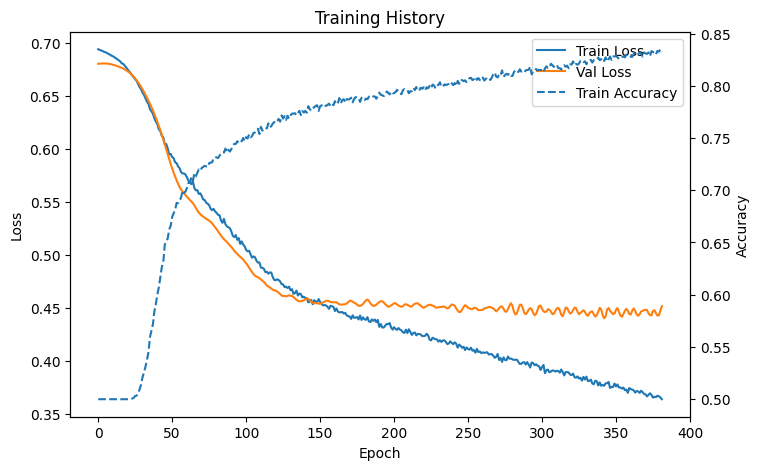

In [34]:
import matplotlib.pyplot as plt
fig, ax1 = plt.subplots(figsize=(8,5))

# Loss axis
ax1.plot(train_losses, label="Train Loss")
ax1.plot(val_losses, label="Val Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")

# Accuracy axis
ax2 = ax1.twinx()
ax2.plot(train_accuracies, linestyle='--', label="Train Accuracy")
ax2.set_ylabel("Accuracy")

# Legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2)

plt.title("Training History")
plt.show()

# Predicting the test set result

In [35]:

with torch.no_grad():
    outputs = Classifier(X_test_ten)
    probs = torch.sigmoid(outputs)

In [36]:
preds = (probs >= 0.6).float()
Y_test_ten = Y_test_ten.reshape(-1)

In [37]:
preds = preds.cpu().numpy()

In [38]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(Y_test_ten, preds))
print(confusion_matrix(Y_test_ten, preds))

              precision    recall  f1-score   support

         0.0       0.92      0.84      0.88      1607
         1.0       0.51      0.68      0.59       393

    accuracy                           0.81      2000
   macro avg       0.71      0.76      0.73      2000
weighted avg       0.84      0.81      0.82      2000

[[1352  255]
 [ 125  268]]


In [39]:
for t in [0.4, 0.5, 0.6, 0.7]:
    preds = (probs >= t).float()
    print(f"\nThreshold: {t}")
    print(classification_report(Y_test, preds))


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.93      0.72      0.81      1607
           1       0.40      0.77      0.53       393

    accuracy                           0.73      2000
   macro avg       0.66      0.74      0.67      2000
weighted avg       0.82      0.73      0.76      2000


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.92      0.78      0.85      1607
           1       0.45      0.73      0.55       393

    accuracy                           0.77      2000
   macro avg       0.68      0.75      0.70      2000
weighted avg       0.83      0.77      0.79      2000


Threshold: 0.6
              precision    recall  f1-score   support

           0       0.92      0.84      0.88      1607
           1       0.51      0.68      0.59       393

    accuracy                           0.81      2000
   macro avg       0.71      0.76      0.73      2000
weighted avg       0.84   

In [40]:
# Applying the highest threshold to the model which is 0.7


In [41]:
preds = (probs >= 0.7).float()
Y_test_ten = Y_test_ten.reshape(-1)

In [42]:
preds = preds.cpu().numpy()

In [43]:
print(classification_report(Y_test_ten, preds))
print(confusion_matrix(Y_test_ten, preds))

              precision    recall  f1-score   support

         0.0       0.90      0.91      0.91      1607
         1.0       0.62      0.60      0.61       393

    accuracy                           0.85      2000
   macro avg       0.76      0.76      0.76      2000
weighted avg       0.85      0.85      0.85      2000

[[1465  142]
 [ 157  236]]


In [44]:
# To view the updated weights
print(Classifier.Layer1.weight)

Parameter containing:
tensor([[ 3.5094e-02,  2.5257e-01,  6.7634e-02,  5.4620e-04,  3.4119e-01,
         -1.0277e-01,  6.8712e-02,  2.2697e-01, -4.5657e-02,  3.4953e-01,
          4.5417e-02,  2.4593e-02],
        [ 1.8486e-01,  3.1142e-02,  2.5341e-01, -2.6749e-01,  4.3820e-02,
          2.3128e-01,  8.6133e-02, -1.4402e-01,  1.5675e-01,  3.5577e-01,
          1.2397e-01,  1.9100e-02],
        [ 2.0801e-01, -1.2297e-03,  1.1526e-01,  9.9314e-02, -2.8738e-01,
         -5.3014e-02,  4.4468e-01, -2.9968e-02,  3.4634e-01, -2.0186e-01,
          2.0115e-01,  1.1120e-02],
        [-2.6707e-01,  3.7253e-01, -1.1110e-01,  7.0308e-02, -2.9382e-01,
         -6.2645e-02,  4.0792e-01, -1.8599e-01,  4.8107e-02,  3.1083e-01,
         -3.2783e-01, -1.0957e-01],
        [-2.3179e-01, -1.1510e-02, -1.2612e-01, -3.9105e-02, -2.8639e-01,
         -6.6980e-03, -1.5846e-01, -7.5836e-02,  1.8120e-01, -2.5951e-01,
          3.4008e-01, -9.6509e-02],
        [ 1.3836e-02,  4.0948e-02,  3.0125e-02,  6.7856e-0

In [45]:
# Improvments
# Apply logistic regression
# Apply random forest
# Apply ROC curve

# Feature Importance Analysis
Since the ANN does not expose built-in feature importances, we use two surrogate tree-based models:
- **Random Forest** and **Gradient Boosting** — each evaluated with *tree-based* and *permutation* importance.
- Results are normalised (0–1) per method so all four columns are directly comparable in the heatmap.

In [48]:
# ── Feature Importance: Surrogate models ─────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.inspection import permutation_importance
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Feature names after one-hot encoding (matching notebook preprocessing)
feature_names = [
    'CreditScore', 'Age', 'Tenure', 'Balance',
    'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
    'Germany', 'Spain',   # Geography dummies (drop_first=True → France is reference)
    'Female', 'Male'      # Gender dummies
]

# Train surrogate models on the SMOTE-resampled training data
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
gb = GradientBoostingClassifier(n_estimators=200, random_state=42)

rf.fit(X_train_res, Y_train_res)
gb.fit(X_train_res, Y_train_res)

print('RF accuracy:', round(rf.score(X_test, Y_test), 4))
print('GB accuracy:', round(gb.score(X_test, Y_test), 4))

RF accuracy: 0.8385
GB accuracy: 0.8565


In [49]:
# ── Permutation importance on the held-out test set ───────────────────────────
perm_rf = permutation_importance(rf, X_test, Y_test, n_repeats=10, random_state=42, n_jobs=-1)
perm_gb = permutation_importance(gb, X_test, Y_test, n_repeats=10, random_state=42, n_jobs=-1)

# Build a DataFrame with all four importance vectors
importance_df = pd.DataFrame({
    'RF Tree-based':  rf.feature_importances_,
    'RF Permutation': perm_rf.importances_mean,
    'GB Tree-based':  gb.feature_importances_,
    'GB Permutation': perm_gb.importances_mean,
}, index=feature_names)

# Normalise each column to [0, 1] so methods are comparable
importance_norm = importance_df.apply(
    lambda c: (c - c.min()) / (c.max() - c.min() + 1e-9)
)

print(importance_df.round(4))

                 RF Tree-based  RF Permutation  GB Tree-based  GB Permutation
CreditScore             0.1052         -0.0016         0.0085          0.0000
Age                     0.2696          0.0716         0.3916          0.0863
Tenure                  0.0928          0.0017         0.1585         -0.0018
Balance                 0.1349          0.0200         0.0597          0.0113
NumOfProducts           0.1668          0.0717         0.2717          0.0667
HasCrCard               0.0171          0.0006         0.0003         -0.0003
IsActiveMember          0.0411          0.0199         0.0547          0.0283
EstimatedSalary         0.1104         -0.0040         0.0104         -0.0034
Germany                 0.0268          0.0124         0.0303          0.0144
Spain                   0.0142         -0.0018         0.0016         -0.0009
Female                  0.0106         -0.0053         0.0086          0.0020
Male                    0.0105         -0.0059         0.0040   

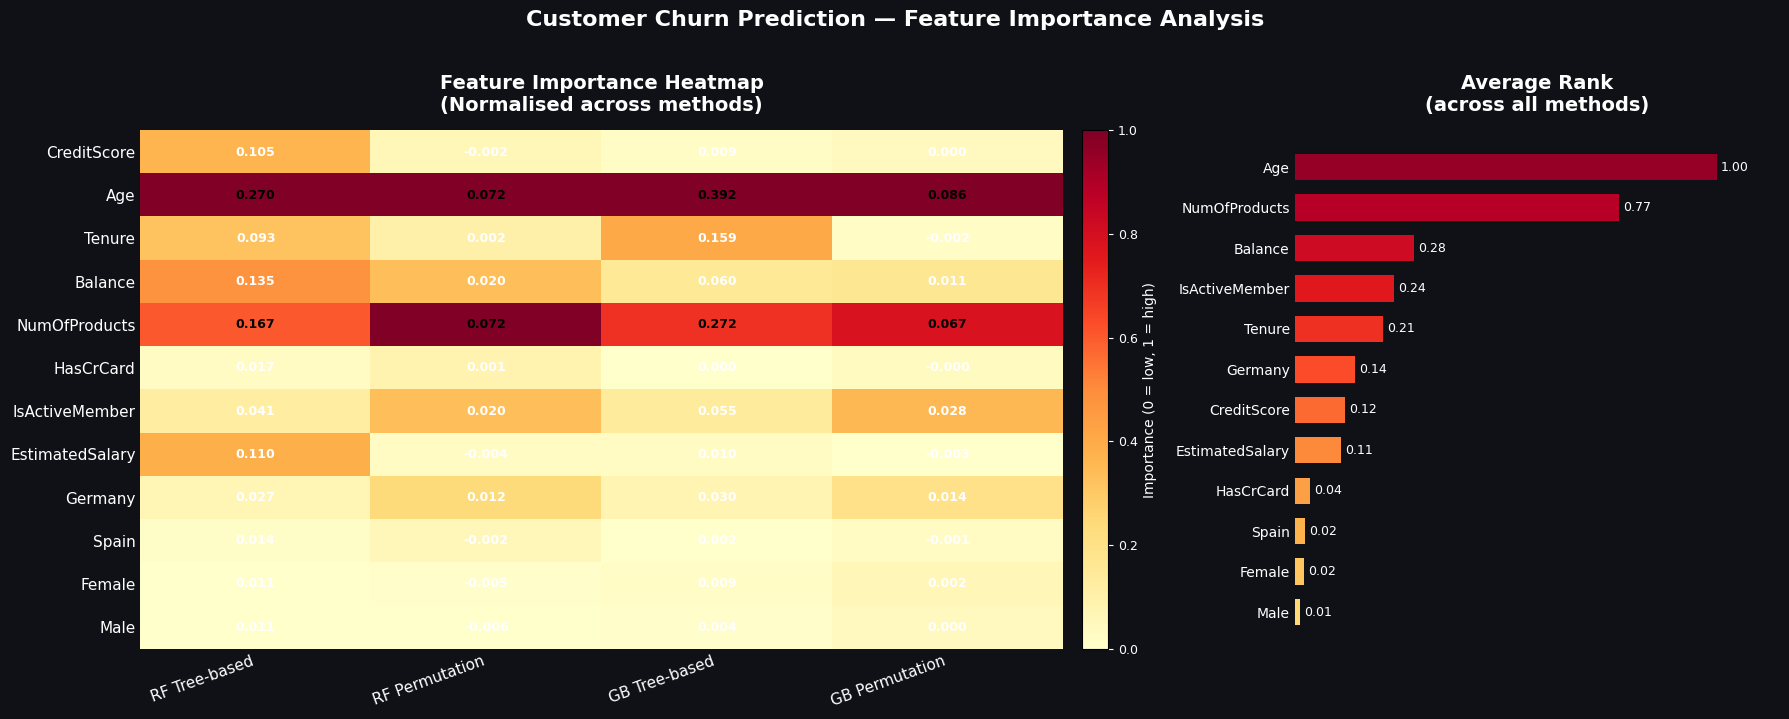

In [50]:
# ── Feature Importance Heatmap ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7),
                         gridspec_kw={'width_ratios': [2, 1]})
fig.patch.set_facecolor('#0f1117')

# ── Left panel: heatmap ───────────────────────────────────────────────────────
ax = axes[0]
ax.set_facecolor('#0f1117')

im = ax.imshow(importance_norm.values, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)

ax.set_xticks(range(len(importance_norm.columns)))
ax.set_xticklabels(importance_norm.columns, color='white', fontsize=11,
                   rotation=20, ha='right')
ax.set_yticks(range(len(feature_names)))
ax.set_yticklabels(feature_names, color='white', fontsize=11)

# Annotate each cell with the raw importance value
for i in range(len(feature_names)):
    for j in range(len(importance_norm.columns)):
        val = importance_norm.values[i, j]
        raw = importance_df.values[i, j]
        txt_color = 'black' if val > 0.6 else 'white'
        ax.text(j, i, f'{raw:.3f}', ha='center', va='center',
                color=txt_color, fontsize=9, fontweight='bold')

ax.set_title('Feature Importance Heatmap\n(Normalised across methods)',
             color='white', fontsize=14, fontweight='bold', pad=14)
ax.tick_params(colors='white', length=0)
for spine in ax.spines.values():
    spine.set_visible(False)

cb = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cb.ax.yaxis.set_tick_params(color='white', labelsize=9)
cb.set_label('Importance (0 = low, 1 = high)', color='white', fontsize=10)
plt.setp(plt.getp(cb.ax.axes, 'yticklabels'), color='white')

# ── Right panel: mean rank bar chart ─────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor('#0f1117')

mean_imp = importance_norm.mean(axis=1).sort_values(ascending=True)
colors   = plt.cm.YlOrRd(np.linspace(0.25, 0.95, len(mean_imp)))
bars     = ax2.barh(mean_imp.index, mean_imp.values,
                    color=colors, edgecolor='none', height=0.65)

for bar, val in zip(bars, mean_imp.values):
    ax2.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
             f'{val:.2f}', va='center', color='white', fontsize=9)

ax2.set_xlim(0, 1.15)
ax2.set_title('Average Rank\n(across all methods)', color='white',
              fontsize=14, fontweight='bold', pad=14)
ax2.tick_params(colors='white', length=0)
for spine in ax2.spines.values():
    spine.set_visible(False)
ax2.xaxis.set_visible(False)
ax2.yaxis.set_tick_params(labelsize=10)
plt.setp(ax2.get_yticklabels(), color='white')

fig.suptitle('Customer Churn Prediction — Feature Importance Analysis',
             color='white', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [51]:
# ── Top-5 summary ─────────────────────────────────────────────────────────────
top5 = importance_norm.mean(axis=1).sort_values(ascending=False).head(5)
print('Top 5 features by mean normalised importance:')
for rank, (feat, score) in enumerate(top5.items(), 1):
    print(f'  {rank}. {feat:<20} {score:.4f}')

Top 5 features by mean normalised importance:
  1. Age                  0.9998
  2. NumOfProducts        0.7695
  3. Balance              0.2826
  4. IsActiveMember       0.2356
  5. Tenure               0.2093
